In [47]:
import rebound
import reboundx
import numpy as np
import matplotlib.pyplot as plt

In [94]:
sim = rebound.Simulation()
sim.integrator = "mercurius"
sim.dt = 0.04*2*np.pi*np.sqrt(5.4**3)
sim.add(m=1, hash = "Sun")
sim.add(m=9.54e-4,a=5.4,e=0.09,hash="Jupiter")
a_sat = 5.2*(2**(2/3))
sim.add(m=9.54e-4,a=a_sat,e=0.07,f=np.pi,hash="Saturn")

a_vals = np.linspace(1,3.5,50)
for i in range(50):
    sim.add(a=a_vals[i], e=0.05,f=np.random.uniform(0,2*np.pi),hash=f"asteroid #{i}")

sim.move_to_com()


print(sim.particles[1].P)
print(sim.particles[2].P)

78.80675559964325
148.867864091294


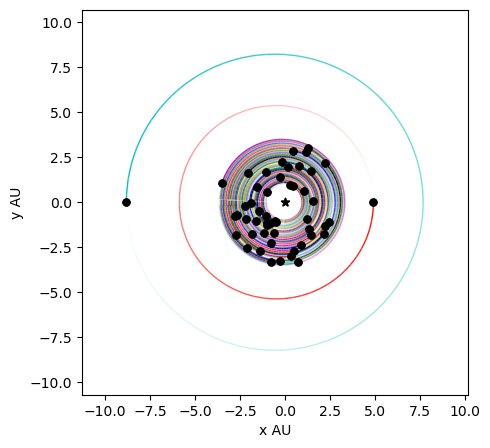

In [95]:
rebound.OrbitPlot(sim,color=True,unitlabel="AU")

In [99]:
sim.integrate(5e4*2*np.pi)

In [100]:
print(sim.particles[1].P)
print(sim.particles[2].P)

78.60044615345187
149.66535524588255


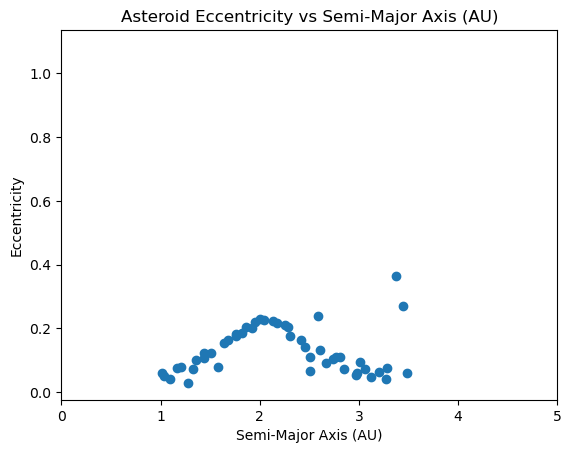

In [101]:
asteroid_eccentricities = np.zeros(50)
asteroid_as = np.zeros(50)

for j in range(50):
    asteroid_eccentricities[j] = sim.particles[3+j].e
    asteroid_as[j] = sim.particles[3+j].a

plt.scatter(asteroid_as,asteroid_eccentricities)
plt.title("Asteroid Eccentricity vs Semi-Major Axis (AU)")
plt.xlabel("Semi-Major Axis (AU)")
plt.ylabel("Eccentricity")
plt.xlim(0,5)
plt.show()

In [108]:
sim2 = rebound.Simulation()
sim2.integrator = "mercurius"
sim2.dt = 0.04*2*np.pi*np.sqrt(5.4**3)
sim2.add(m=1, hash = "Sun")
sim2.add(m=9.54e-4,a=5.4,e=0.09,hash="Jupiter")
a_sat2 = 5.2*(2**(2/3))
sim2.add(m=9.54e-4,a=a_sat2,e=0.07,f=np.pi,hash="Saturn")

sim.move_to_com()

In [109]:
sim2.save_to_file("data.bin", interval = 1000, delete_file = True)

sim2.integrate(1e5*2*np.pi)

snaps = rebound.Simulationarchive("data.bin")

lambda_jupiter = np.array([snap.particles[1].l for snap in snaps])
lambda_saturn = np.array([snap.particles[1].l for snap in snaps])
pomega_saturn = np.array([snap.particles[1].pomega for snap in snaps])
t = np.array([snap.t for snap in snaps])

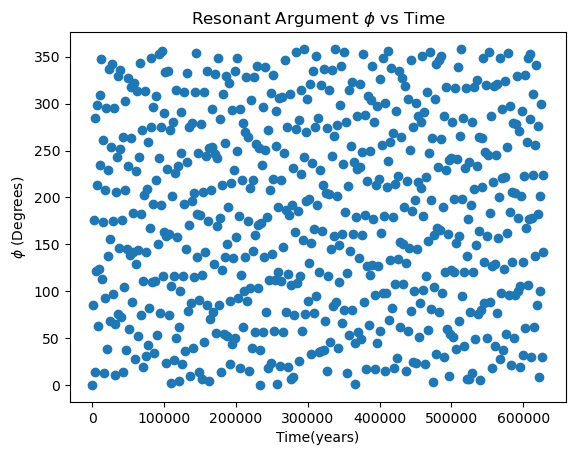

In [114]:
phi = (lambda_jupiter - 2*lambda_saturn + pomega_saturn) % (2*np.pi)

phi = phi*180/np.pi

plt.scatter(t,phi)
plt.xlabel("Time(years)")
plt.title(r"Resonant Argument $\phi$ vs Time")
plt.ylabel(r"$\phi$ (Degrees)")
plt.show()